In [1]:
import sys
import importlib
from pathlib import Path
import pvlib
from scipy.interpolate import BSpline

# go from ...\docs\tutorials up two levels to the repo root (...\darkgreybox)
repo_root = Path.cwd().parents[1]
sys.path.insert(0, str(repo_root))
importlib.invalidate_caches()


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold
from statsmodels.graphics.tsaplots import plot_pacf

from darkgreybox.models import TiTmCn2R2C_summer_V9
from darkgreybox.night_ventilation import simulate_night_vent_scenario, comfort_metrics
from darkgreybox.fit import darkgreyfit
from docs.tutorials.util.plot import plot
from docs.tutorials.util.error import rmse

C:\Users\clemr\AppData\Roaming\Python\Python311\site-packages\matplotlib\projections\__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


2026-05-10 19:50:17,710 darkgreybox  INFO     Logging enabled...


In [2]:
rec_duration = 15/60

In [3]:
import pickle

class MockResult:
    def __init__(self, Z, var=None):
        self.Z   = Z
        self.var = var if var is not None else {}

RESULTS_FILE = "simulation_results_mcmc_2025_05_mcmcindic.pkl"

with open(RESULTS_FILE, "rb") as f:
    saved = pickle.load(f)

df           = saved["df"]
X_train      = saved["X_train"]
y_train      = saved["y_train"]
X_test       = saved["X_test"]
y_test       = saved["y_test"]
model        = saved["model"]

train_results = saved["train_results"]
test_results  = saved["test_results"]

print(f"Loaded! DataFrame shape: {df.shape}")

Loaded! DataFrame shape: (1, 13)


In [7]:
# Define training parameters
train_params_TiTmCn2R2C_summer_V4 = {
    'Ti0': {'value': input_df.iloc[0]['Ti0'], 'vary': False},               # Initial indoor temperature
    'Tm0': {'value': input_df.iloc[0]['Tm0'], 'vary': False},               # Initial thermal mass temperature
    'c0': {'value': input_df.iloc[0]['c0'], 'vary': False},                 # Initial CO2 concentration
    'N0': {'value': input_df.iloc[0]['N0'], 'vary': False},                 # Initial number of occupants
    
    #'Ci': {'value': Ci_i, 'vary': True, 'min': Ci_min, 'max': Ci_max},      # Air + light internal components heat capacity at air node (fast mass at Ti)
    #'Cm': {'value': Cm_i, 'vary': True, 'min': Cm_min, 'max': Cm_max},      # Thermal mass heat capacity (heavy structural mass at Tm)
    #'Rim': {'value': Rim_i, 'vary': True, 'min': Rim_min, 'max': Rim_max},  # Thermal resistance indoor air ↔ thermal mass (heat air ↔ building structure)
    #'Rout': {'value': Rout_i, 'vary': True, 'min': Rout_min, 'max': Rout_max},  # Overall thermal resistance indoor air ↔ ambient/outdoor air (heat loss path)
    'Ci': {'value': 1000.19534, 'vary': True, 'min': 1000, 'max': 10000},
    'Cm': {'value': 4167.99849, 'vary': True, 'min': 1000, 'max': 50000},    # Bigger mass\n",
    'Rim': {'value': 0.00153473, 'vary': True, 'min': 0.001, 'max': 0.01},           # Mass-air  \n",
    'Rout': {'value': 0.08885421, 'vary': True, 'min': 0.01, 'max': 1},         # Envelope\n",
    'q_pers': {'value': 75, 'vary': False},                                 # Internal gains per person
    'q_equip_var': {'value': 80, 'vary': False},                            # Variable equipment gains per person
    'q_equip_const': {'value': 10, 'vary': False},                          # Constant equipment gains
    'V': {'value': S_room*H_room, 'vary': False},                           # Volume of the room
    'S': {'value': S_room, 'vary': False},                                  # Surface of the room
    'A': {'value': A_windows, 'vary': False},                               # Window area
    'G': {'value': 0.016, 'vary': False},                                   # Global radiation factor
    'c_out': {'value': 400, 'vary': False},                                 # Outdoor CO2 concentration
    'rho_air': {'value': 1.2, 'vary': False},                               # Air density
    'cp_air': {'value': 1000, 'vary': False},                               # Specific heat capacity of air
    #'g': {'value': 0.55, 'vary': False},                                    # total solar energy transmittance of the glazing 
    'alpha': {'value': 0.1, 'vary': True, 'min': 0.01, 'max': 0.5},         # CO2 occupancy filter parameter
    'gamma_g': {'value': orientation, 'vary': False},                    # glazing angle for IAM calculation
    'n': {'value': 1.526, 'vary': False},                                        # refractive index for IAM calculation
    'K': {'value': 4, 'vary': False},                                   # absorption coefficient for IAM calculation (1/m)
    'L': {'value': 0.003, 'vary': False},                                     # glazing thickness for IAM calculation (m)
    'Rneigh_1': {'value': Rneih_1_i, 'vary': True, 'min': Rneih_1_i*0.1, 'max': Rneih_1_i*10},         # Thermal resistance between the room and the neighboring spaces (simplified representation of heat transfer through internal walls)
    'Rneigh_2': {'value': Rneih_2_i, 'vary': True, 'min': Rneih_2_i*0.1, 'max': Rneih_2_i*10},         # Thermal resistance between the room and the neighboring spaces (simplified representation of heat transfer through internal walls)
    'f_sol': {'value': 0.4, 'vary': True, 'min': 0, 'max': 1},         # Solar gains distribution factor (fraction of solar gains directly affecting indoor air node)
    # 10 B-spline coefficients
    'phi_a': {'value': 0.7, 'vary': True, 'min': 0, 'max': 1},
    'phi_b': {'value': 0.7, 'vary': True, 'min': 0, 'max': 1},
    'phi_c': {'value': 0.7, 'vary': True, 'min': 0, 'max': 1},
    'phi_d': {'value': 0.7, 'vary': True, 'min': 0, 'max': 1},
    'phi_e': {'value': 0.7, 'vary': True, 'min': 0, 'max': 1},
    'phi_f': {'value': 0.7, 'vary': True, 'min': 0, 'max': 1},
    'phi_g': {'value': 0.7, 'vary': True, 'min': 0, 'max': 1},  
    'phi_h': {'value': 0.7, 'vary': True, 'min': 0, 'max': 1},
    'phi_i': {'value': 0.7, 'vary': True, 'min': 0, 'max': 1},
    'phi_j': {'value': 0.7, 'vary': True, 'min': 0, 'max': 1},
}


def run_model_with_theta_and_ic(theta, X_dict_train, X_dict_test, y_train_arr, params_template):
    """
    Step 1: run on training set → extract final states (Tm, c, N)
    Step 2: set test ICs from those final states + y_test[0] for Ti0
    Step 3: run on test set
    """
    import copy, lmfit

    def make_params(extra_ic=None):
        params = _as_lmfit_params(params_template)
        for name, val in zip(PARAM_NAMES, theta):
            params[name].value = float(val)
        if extra_ic:
            for k, v in extra_ic.items():
                params[k].value = float(v)
        return params

    # Step 1 — training run to get final states
    p_train = make_params()
    m_train = TiTmCn2R2C_summer_V9(p_train, rec_duration)
    r_train = m_train.model(p_train, X_dict_train)
    Ti_train = np.asarray(r_train.Z, dtype=float)

    # Step 2 — build test initial conditions
    test_ic = {
        'Ti0': y_train_arr[-1],                         # last observed Ti in train
        'Tm0': r_train.var['Tm'][-1] if 'Tm' in r_train.var else y_train_arr[-1],
        'c0':  r_train.var['c'][-1]  if 'c'  in r_train.var else params_template['c0']['value'],
        'N0':  r_train.var['N'][-1]  if 'N'  in r_train.var else 0.0,
    }

    # Step 3 — test run with correct ICs
    p_test = make_params(extra_ic=test_ic)
    m_test = TiTmCn2R2C_summer_V9(p_test, rec_duration)
    r_test = m_test.model(p_test, X_dict_test)
    Ti_test = np.asarray(r_test.Z, dtype=float)

    return Ti_train, Ti_test

# ================================================================
# UNCERTAINTY DECOMPOSITION — full analysis + figure
# ================================================================
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from scipy.stats import median_abs_deviation


# ── 0. Observation noise: known sensor spec + MAD diagnostic ─────
# Sensor datasheet noise: σ_obs = 0.0435 °C  ← use as ground truth
SIGMA_OBS_SENSOR = 0.0435   # °C — known sensor noise (replaces MAD estimate)

residuals_map = y_obs_train - np.asarray(train_results.Z, dtype=float)
sigma_obs_std = float(np.std(residuals_map))
sigma_obs_mad = float(median_abs_deviation(residuals_map, scale='normal'))
sigma_obs     = SIGMA_OBS_SENSOR   # ← now uses known sensor spec, not MAD

print(f"  σ_obs (sensor spec, ground truth) : {sigma_obs:.4f} °C  ← used in decomposition")
print(f"  σ_obs from MAP residuals (MAD)    : {sigma_obs_mad:.4f} °C  ← diagnostic reference")
print(f"  σ_obs from MAP residuals (std)    : {sigma_obs_std:.4f} °C  ← inflated by occupancy spikes")
print(f"  MAD / sensor ratio                : {sigma_obs_mad/sigma_obs:.2f}  (1.0 = perfect match)")
print(f"  std / MAD  ratio                  : {sigma_obs_std/sigma_obs_mad:.2f}  (>1 → heavy tails in residuals)")


# ── 1. Build CI-based samples (per-parameter Gaussian from credible interval)
rng_ci     = np.random.default_rng(99)
n_ci       = 300
ci_samples = np.zeros((n_ci, ndim))

for i, name in enumerate(PARAM_NAMES):
    p16, p50, p84 = np.percentile(flat_samples[:, i], [16, 50, 84])
    sigma_avg     = ((p50 - p16) + (p84 - p50)) / 2.0
    lo, hi        = BOUNDS[name]
    draws = rng_ci.normal(loc=p50, scale=sigma_avg, size=n_ci * 5)
    draws = draws[(draws >= lo) & (draws <= hi)][:n_ci]
    ci_samples[:, i] = draws

print("\n  Running CI-based predictive check (300 samples)...")
Ti_ci_train = np.stack([
    run_model_with_theta_and_ic(
        ci_samples[i], X_dict_train, X_dict_test, y_obs_train,
        train_params_TiTmCn2R2C_summer_V4)[0]
    for i in range(n_ci)
])
Ti_ci_test = np.stack([
    run_model_with_theta_and_ic(
        ci_samples[i], X_dict_train, X_dict_test, y_obs_train,
        train_params_TiTmCn2R2C_summer_V4)[1]
    for i in range(n_ci)
])


# ── 2. Compute all band quantities ───────────────────────────────
def decompose(ens, y_obs, sigma_obs):
    mu    = ens.mean(axis=0)
    sp    = ens.std(axis=0)
    st    = np.sqrt(sp**2 + sigma_obs**2)
    cov_p = np.mean((y_obs >= mu-2*sp) & (y_obs <= mu+2*sp)) * 100
    cov_t = np.mean((y_obs >= mu-2*st) & (y_obs <= mu+2*st)) * 100
    return mu, sp, st, cov_p, cov_t

mu_tr, sp_tr, st_tr, cov_p_tr, cov_t_tr = decompose(Ti_ci_train, y_obs_train, sigma_obs)
mu_te, sp_te, st_te, cov_p_te, cov_t_te = decompose(Ti_ci_test,  y_obs_test,  sigma_obs)


# ── 3. Print summary ─────────────────────────────────────────────
print("\n" + "="*62)
print("  UNCERTAINTY DECOMPOSITION")
print("="*62)
print(f"\n  σ_obs source: known sensor spec ({sigma_obs:.4f} °C)")
print(f"  Residual MAD={sigma_obs_mad:.4f} °C  (ratio MAD/sensor "
      f"= {sigma_obs_mad/sigma_obs:.2f})  "
      f"[residual std={sigma_obs_std:.4f}, ratio={sigma_obs_std/sigma_obs_mad:.2f}]\n")
print(f"  {'':35s}  {'Train':>8}  {'Test':>8}")
print(f"  {'─'*55}")
print(f"  {'Parametric σ  [°C]':35s}  {sp_tr.mean():>8.4f}  {sp_te.mean():>8.4f}")
print(f"  {'Observation noise σ_obs (sensor) [°C]':35s}  {sigma_obs:>8.4f}  {sigma_obs:>8.4f}")
print(f"  {'Total prediction σ  [°C]':35s}  {st_tr.mean():>8.4f}  {st_te.mean():>8.4f}")
print(f"  {'─'*55}")
print(f"  {'Parametric share  σ_p / σ_total':35s}  "
      f"{sp_tr.mean()/st_tr.mean()*100:>7.1f}%  {sp_te.mean()/st_te.mean()*100:>7.1f}%")
print(f"  {'Noise share  σ_obs / σ_total':35s}  "
      f"{sigma_obs/st_tr.mean()*100:>7.1f}%  {sigma_obs/st_te.mean()*100:>7.1f}%")
print(f"  {'─'*55}")
print(f"  {'±2σ coverage — parametric only':35s}  {cov_p_tr:>7.1f}%  {cov_p_te:>7.1f}%")
print(f"  {'±2σ coverage — total (target~95%)':35s}  {cov_t_tr:>7.1f}%  {cov_t_te:>7.1f}%")
print(f"\n  Interpretation:")
print(f"  → Knowing parameters better would reduce σ_total by only "
      f"{(1 - sp_tr.mean()/st_tr.mean())*100:.0f}%")
print(f"  → Dominant uncertainty source: sensor noise "
      f"({sigma_obs/st_tr.mean()*100:.0f}% of total)")


# ── 4. Figure ────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig,
                        height_ratios=[2.2, 1],
                        hspace=0.42, wspace=0.30)

ax_tr  = fig.add_subplot(gs[0, 0])
ax_te  = fig.add_subplot(gs[0, 1])
ax_bar = fig.add_subplot(gs[1, 0])
ax_cov = fig.add_subplot(gs[1, 1])


# ── Panel A & B: predictions with both bands ─────────────────────
for ax, mu, sp, st, y_obs, Ti_map, label, col in [
    (ax_tr, mu_tr, sp_tr, st_tr, y_obs_train, Ti_map_train, "Train", "steelblue"),
    (ax_te, mu_te, sp_te, st_te, y_obs_test,  Ti_map_test,  "Test",  "darkorange"),
]:
    t = np.arange(len(y_obs))
    ax.fill_between(t, mu - 2*st, mu + 2*st,
                    color=col, alpha=0.15,
                    label=f"±2σ total  = {st.mean():.3f} °C")
    ax.fill_between(t, mu - 2*sp, mu + 2*sp,
                    color=col, alpha=0.55,
                    label=f"±2σ param  = {sp.mean():.3f} °C")
    ax.plot(t, y_obs,  "k-",  lw=1.0, label="Observed Tᵢ")
    ax.plot(t, Ti_map, "r--", lw=1.0, label="MAP (Nelder-Mead)")
    ax.plot(t, mu,     "-",   lw=1.4, color=col, label="MCMC median")
    ax.set_title(f"{label} period", fontsize=11)
    ax.set_xlabel("Time step [5 min]")
    ax.set_ylabel("Indoor temperature [°C]")
    ax.legend(fontsize=8, loc="upper right")


# ── Panel C: uncertainty budget (stacked bar) ────────────────────
periods   = ["Train", "Test"]
sp_vals   = [sp_tr.mean(), sp_te.mean()]
noise_add = [np.sqrt(sigma_obs**2 + sp_tr.mean()**2) - sp_tr.mean(),
             np.sqrt(sigma_obs**2 + sp_te.mean()**2) - sp_te.mean()]
x_bar = np.arange(2)

b1 = ax_bar.bar(x_bar, sp_vals,   0.45, label="Parametric σ",
                color="#4f98a3", alpha=0.9)
b2 = ax_bar.bar(x_bar, noise_add, 0.45, bottom=sp_vals,
                label=f"Added by sensor noise (σ_obs={sigma_obs:.4f} °C)",
                color="#d4a843", alpha=0.9)

for i, (sp, na) in enumerate(zip(sp_vals, noise_add)):
    tot = sp + na
    ax_bar.text(i, sp/2,       f"{sp:.3f}",  ha="center", va="center",
                fontsize=9, color="white", fontweight="bold")
    ax_bar.text(i, sp + na/2,  f"+{na:.3f}", ha="center", va="center",
                fontsize=9, color="white", fontweight="bold")
    ax_bar.text(i, tot + 0.005, f"= {tot:.3f} °C", ha="center", va="bottom",
                fontsize=9, color="black")

ax_bar.set_xticks(x_bar)
ax_bar.set_xticklabels(periods)
ax_bar.set_ylabel("σ [°C]")
ax_bar.set_title("Uncertainty budget", fontsize=11)
ax_bar.legend(fontsize=9)
ax_bar.set_ylim(0, max(sp_vals[0]+noise_add[0],
                       sp_vals[1]+noise_add[1]) * 1.25)


# ── Panel D: coverage bars ────────────────────────────────────────
x_cov = np.arange(2)
w     = 0.30
bars1 = ax_cov.bar(x_cov - w/2, [cov_p_tr, cov_p_te], w,
                   label="Parametric only", color="#4f98a3", alpha=0.9)
bars2 = ax_cov.bar(x_cov + w/2, [cov_t_tr, cov_t_te], w,
                   label="Total (param + sensor noise)", color="#d4a843", alpha=0.9)

ax_cov.axhline(95, color="green", ls="--", lw=1.5, label="95% target")
ax_cov.set_ylim(0, 115)
ax_cov.set_xticks(x_cov)
ax_cov.set_xticklabels(periods)
ax_cov.set_ylabel("Coverage [%]")
ax_cov.set_title("±2σ coverage comparison", fontsize=11)
ax_cov.legend(fontsize=8)

for bar, val in [(b, v) for bars, vals in
                 [(bars1, [cov_p_tr, cov_p_te]),
                  (bars2, [cov_t_tr, cov_t_te])]
                 for b, v in zip(bars, vals)]:
    ax_cov.text(bar.get_x() + bar.get_width()/2, val + 1.5,
                f"{val:.1f}%", ha="center", fontsize=9, fontweight="bold")


# ── Overall title ─────────────────────────────────────────────────
fig.suptitle(
    "Uncertainty decomposition — MCMC posterior predictive check\n"
    f"Parametric share: {sp_tr.mean()/st_tr.mean()*100:.1f}%  |  "
    f"Noise share: {sigma_obs/st_tr.mean()*100:.1f}%  |  "
    f"σ_obs = {sigma_obs:.4f} °C  (sensor spec)  "
    f"[MAD={sigma_obs_mad:.4f}, std={sigma_obs_std:.4f}]",
    fontsize=12, y=1.01
)

plt.savefig("mcmc_uncertainty_decomposition.png", dpi=150, bbox_inches="tight")
plt.show()
print("  → mcmc_uncertainty_decomposition.png saved")

NameError: name 'input_df' is not defined

Loaded — 8,640 posterior samples, 18 parameters

  1. SAMPLER HEALTH

  Acceptance fraction : 0.021  ⚠ TOO LOW  — walkers stuck, widen bounds or increase nsteps
  (target range: 0.20 – 0.50)

  Parameter         tau   50×tau      ESS  Status
  --------------------------------------------------
  Ci              185.5     9277       47  ⚠ need more steps
  Cm              185.0     9251       47  ⚠ need more steps
  Rim             174.0     8698       50  ⚠ need more steps
  Rout            184.6     9231       47  ⚠ need more steps
  alpha           179.8     8988       48  ⚠ need more steps
  Rneigh_1        174.1     8706       50  ⚠ need more steps
  Rneigh_2        181.5     9073       48  ⚠ need more steps
  f_sol           182.6     9129       47  ⚠ need more steps
  phi_a           179.1     8955       48  ⚠ need more steps
  phi_b           179.5     8977       48  ⚠ need more steps
  phi_c           185.8     9292       46  ⚠ need more steps
  phi_d           184.4     9218  

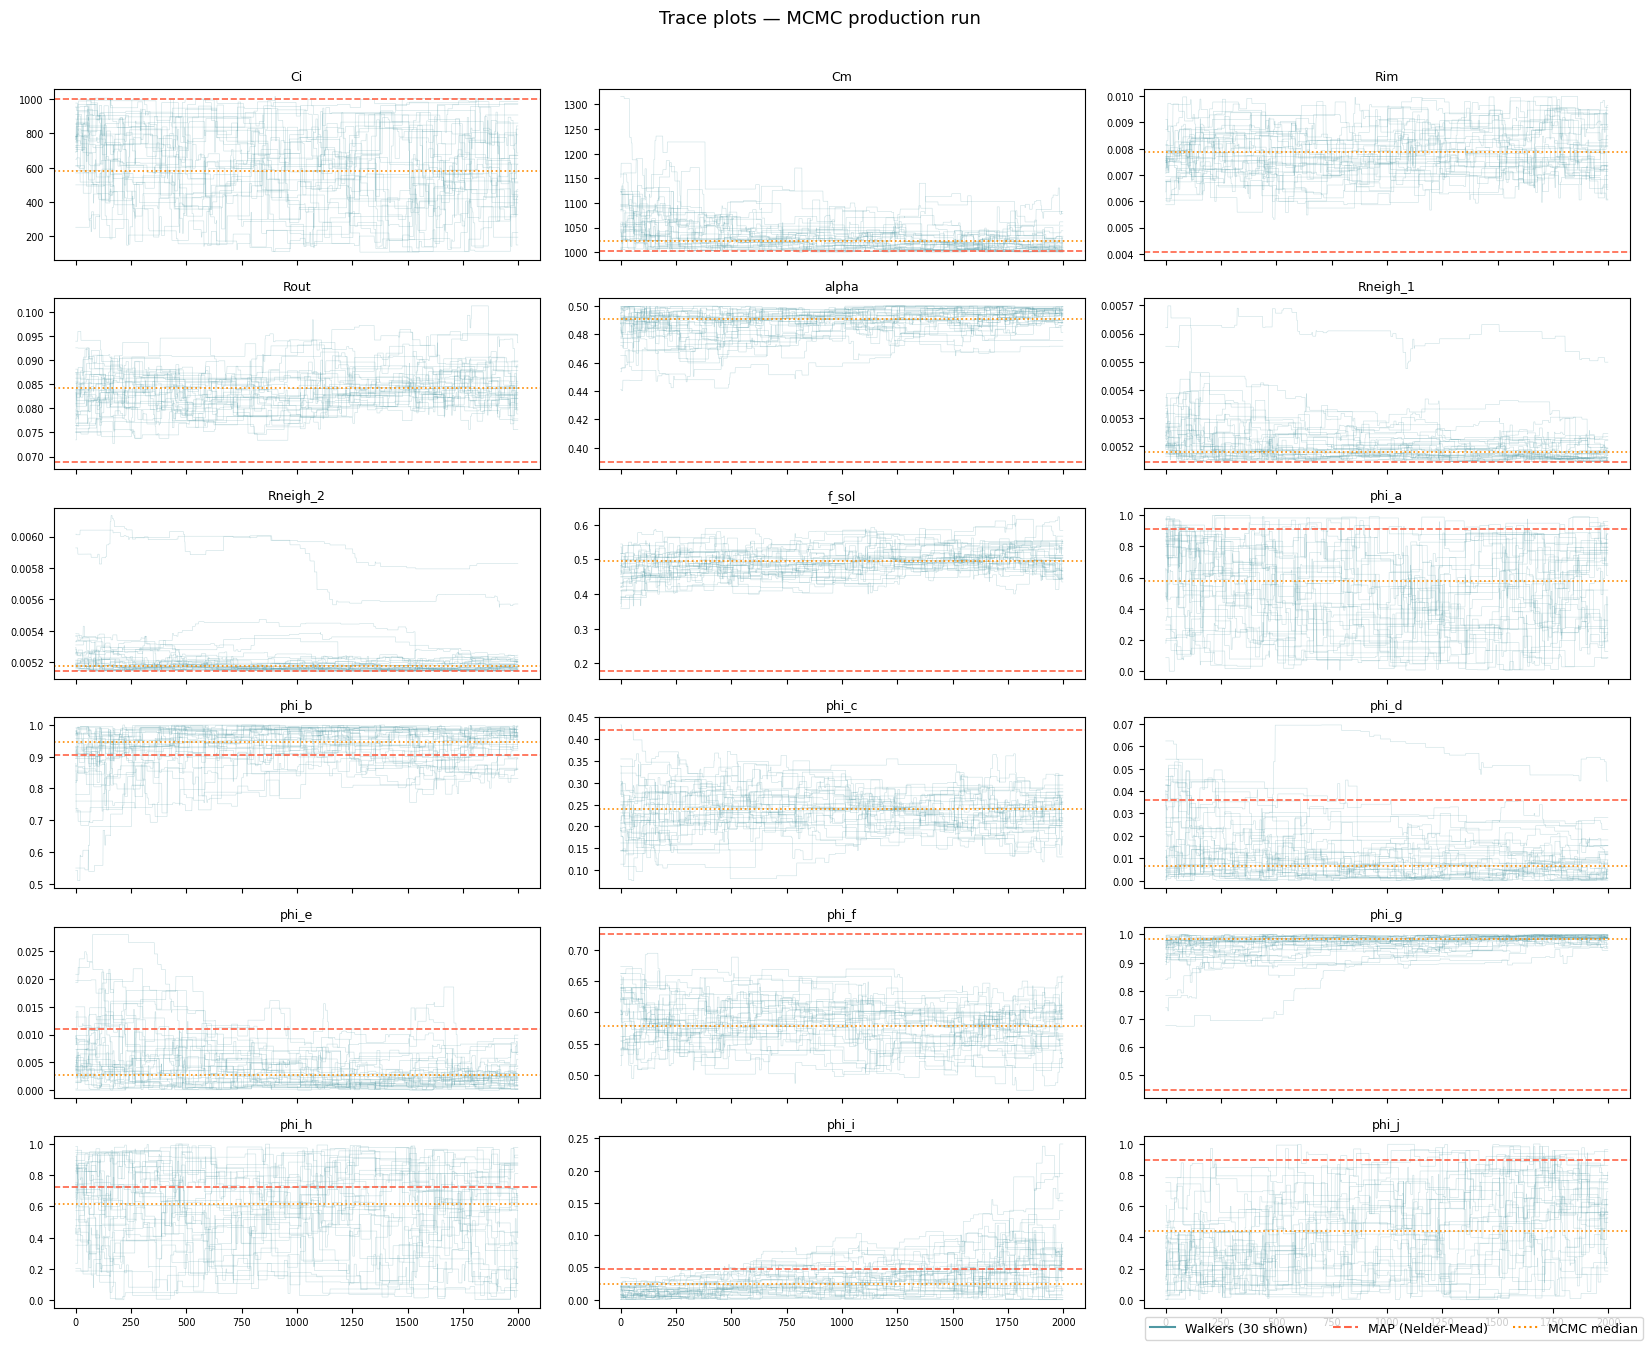


  → mcmc_trace_plots.png saved
2026-05-10 19:55:10,836 root         WARNING  Too few points to create valid contours
2026-05-10 19:55:13,652 root         WARNING  Too few points to create valid contours


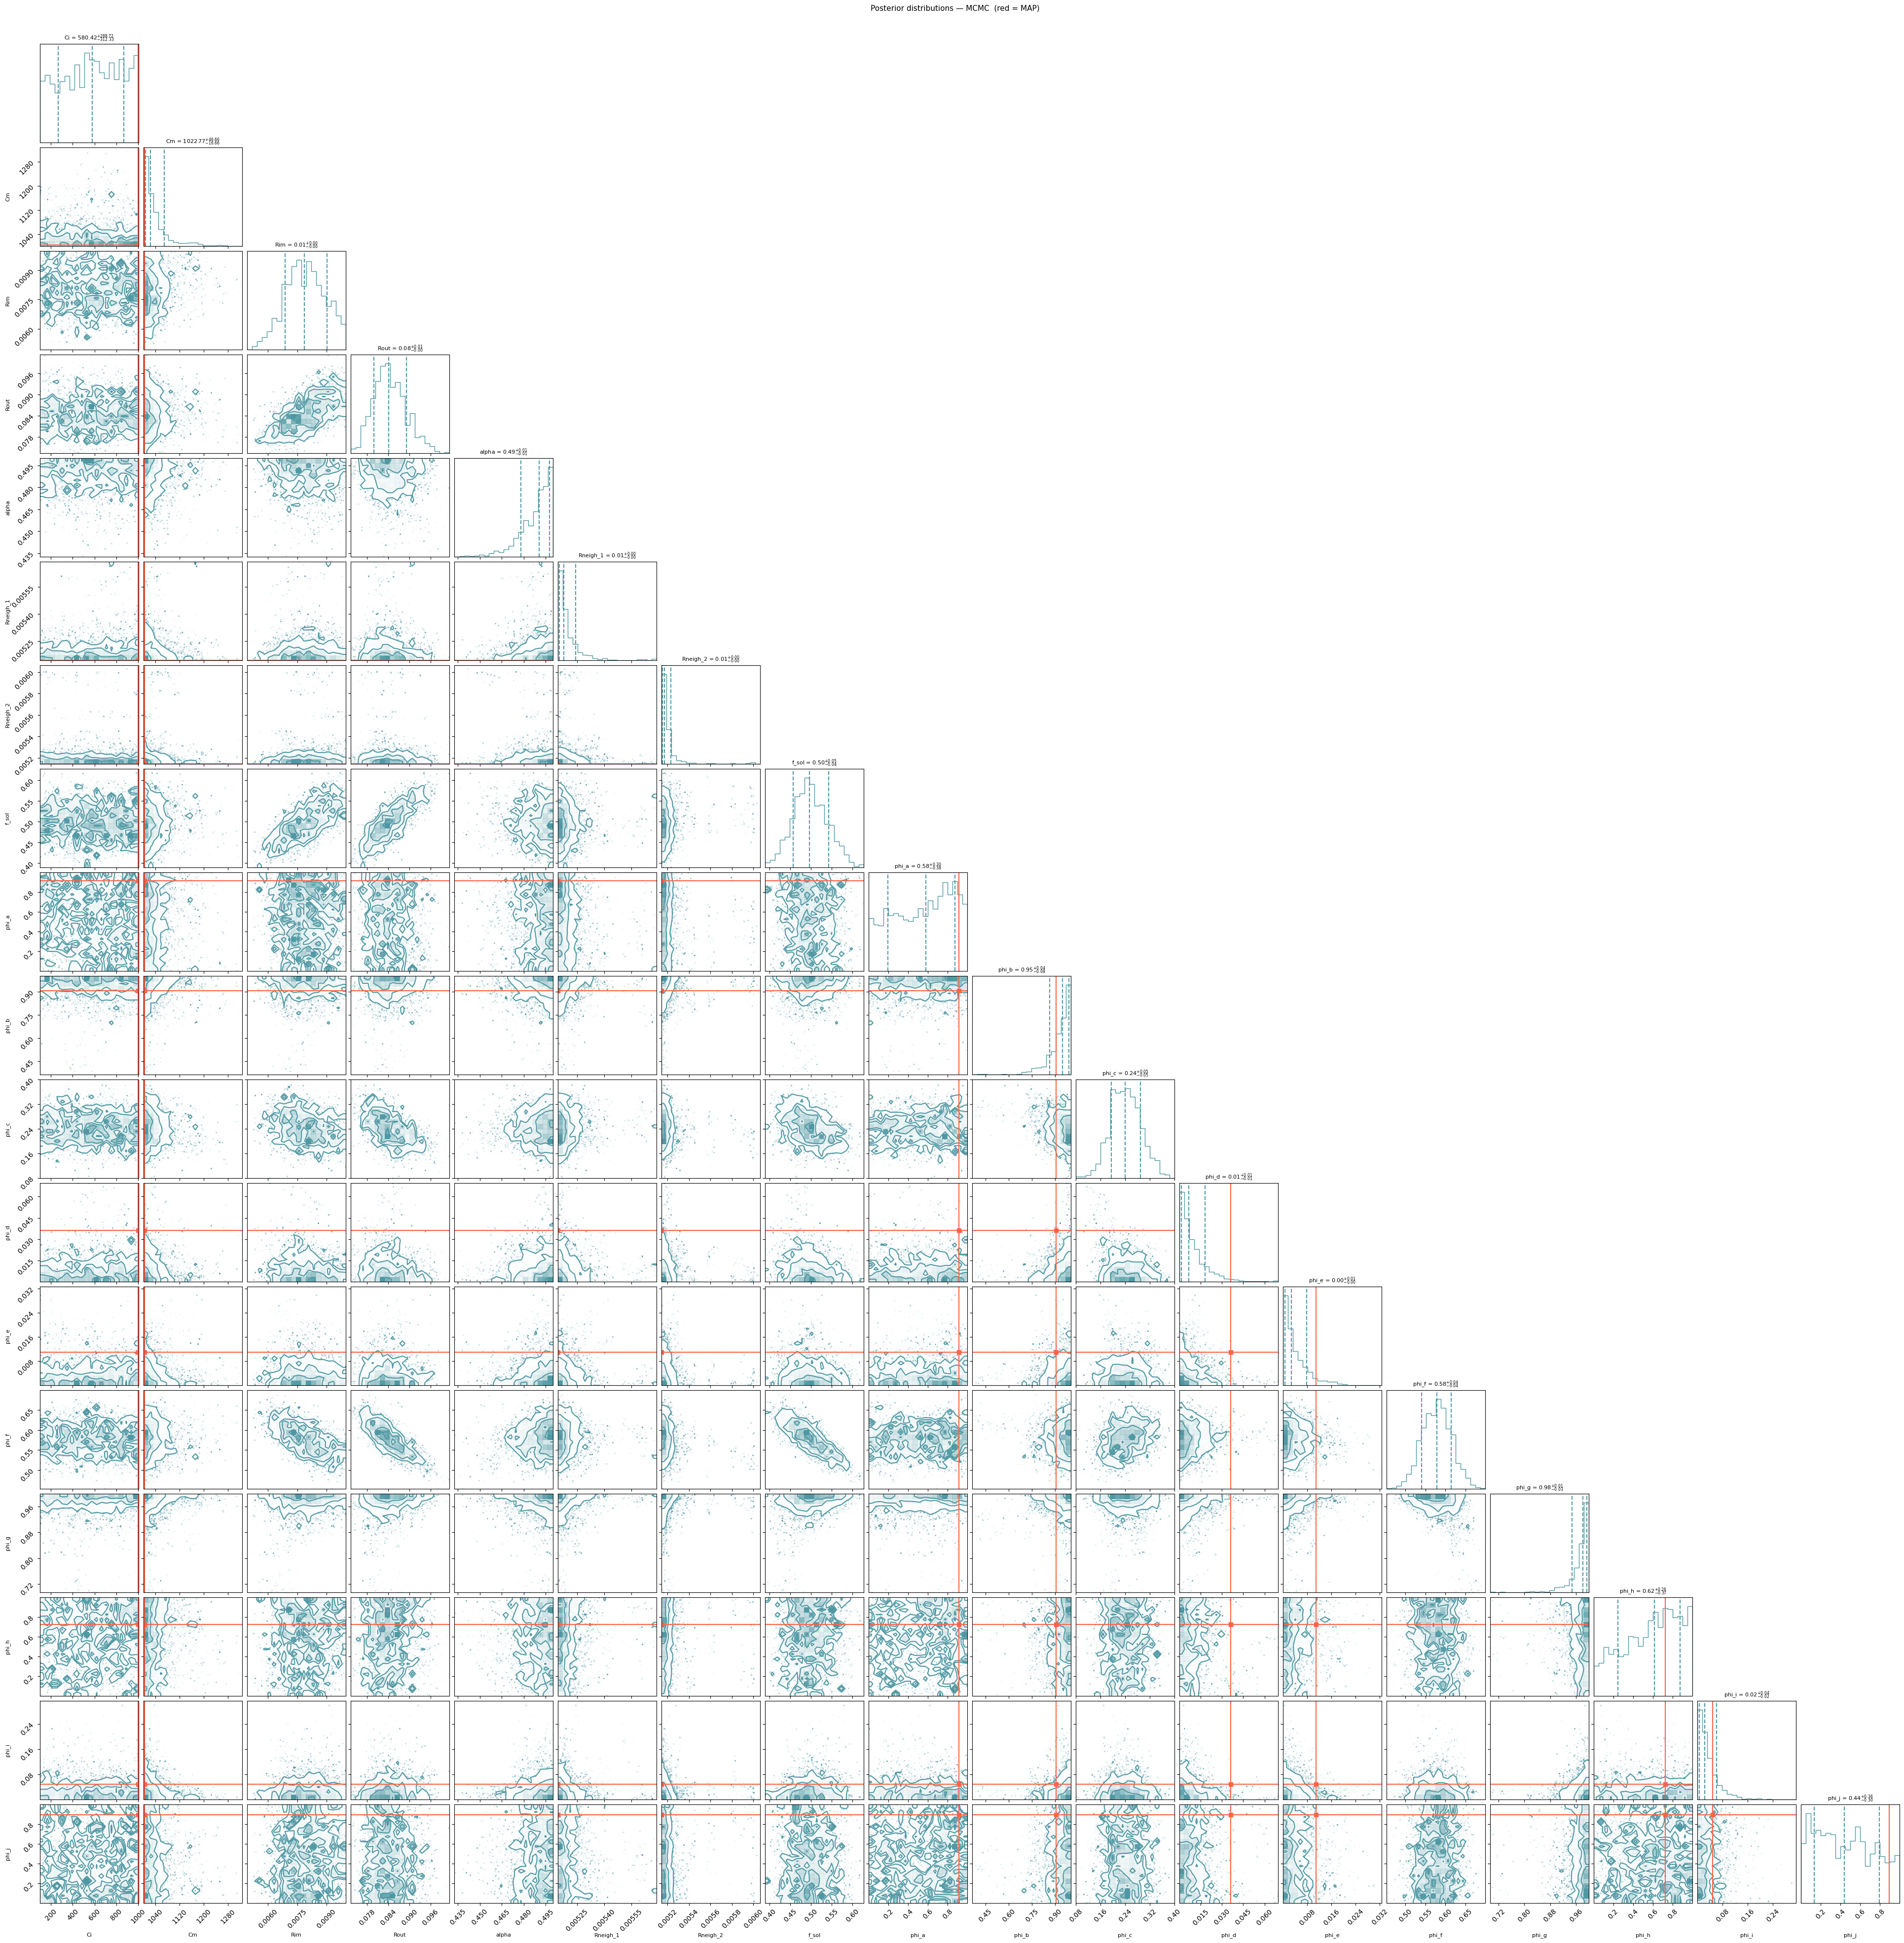

  → mcmc_corner_plot.png saved

  4. PARAMETER ESTIMATES


,Parameter,MAP,Median,-1σ,+1σ,Δ MAP→med %,Bounds,Status
0,Ci,1000,580.42,312.33,288.72,42.0,"[100, 1e+04]",⚠ lower bound
1,Cm,1003.2,1022.8,16.658,46.663,2.0,"[1e+03, 5e+04]",⚠ lower bound
2,Rim,0.0040646,0.0078785,0.00099188,0.0011589,93.8,"[0.001, 0.01]",✓
3,Rout,0.068939,0.084123,0.0041293,0.0051208,22.0,"[0.01, 1]",✓
4,alpha,0.39028,0.49067,0.012623,0.0068262,25.7,"[0.01, 0.5]",⚠ upper bound
5,Rneigh_1,0.0051441,0.0051773,2.3836e-05,6.5604e-05,0.6,"[0.00514, 0.514]",⚠ lower bound
6,Rneigh_2,0.0051451,0.0051741,2.2233e-05,5.8293e-05,0.6,"[0.00514, 0.514]",⚠ lower bound
7,f_sol,0.17741,0.49616,0.038308,0.046815,179.7,"[0, 1]",✓
8,phi_a,0.91408,0.5786,0.38283,0.29844,36.7,"[0, 1]",✓
9,phi_b,0.90464,0.94633,0.083741,0.040184,4.6,"[0, 1]",⚠ upper bound



  Computing MCMC median predictions ...


NameError: name 'train_params_TiTmCn2R2C_summer_V4' is not defined

In [8]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from scipy import stats
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_squared_error
import corner
import warnings
warnings.filterwarnings("ignore")

# ================================================================
# 0. LOAD
# ================================================================
RESULTS_FILE = "simulation_results_mcmc_2025_05_mcmcindic.pkl"

with open(RESULTS_FILE, "rb") as f:
    saved = pickle.load(f)

df            = saved["df"]
X_train       = saved["X_train"]
y_train       = saved["y_train"]
X_test        = saved["X_test"]
y_test        = saved["y_test"]
model         = saved["model"]
train_results = saved["train_results"]
test_results  = saved["test_results"]

flat_samples  = saved["flat_samples"]
full_chain    = saved.get("full_chain", None)
theta_map     = saved["theta_map"]
acc_frac      = saved["acceptance_fraction"]
tau           = saved["autocorr_tau"]
PARAM_NAMES   = saved["param_names"]
BOUNDS        = saved["bounds"]
sigma_obs     = saved.get("sigma_obs", 0.3)

ndim         = len(PARAM_NAMES)
N_samples    = flat_samples.shape[0]
theta_mcmc   = np.array([np.percentile(flat_samples[:, i], 50) for i in range(ndim)])

X_dict_train = {col: X_train[col].values for col in X_train.columns}
X_dict_test  = {col: X_test[col].values  for col in X_test.columns}
y_obs_train  = y_train.values
y_obs_test   = y_test.values

rmse_fn = lambda y, yh: float(np.sqrt(np.mean((np.asarray(y) - np.asarray(yh))**2)))
r2_fn   = lambda y, yh: float(1 - np.sum((np.asarray(y)-np.asarray(yh))**2)
                                   / np.sum((np.asarray(y)-np.mean(y))**2))

print(f"Loaded — {N_samples:,} posterior samples, {ndim} parameters")

# ================================================================
# 1. SAMPLER HEALTH
# ================================================================
print("\n" + "="*62)
print("  1. SAMPLER HEALTH")
print("="*62)

if   acc_frac < 0.10: acc_label = "⚠ TOO LOW  — walkers stuck, widen bounds or increase nsteps"
elif acc_frac > 0.70: acc_label = "⚠ TOO HIGH — proposals too small"
else:                  acc_label = "✓ healthy"
print(f"\n  Acceptance fraction : {acc_frac:.3f}  {acc_label}")
print(f"  (target range: 0.20 – 0.50)\n")

print(f"  {'Parameter':12s}  {'tau':>7}  {'50×tau':>7}  {'ESS':>7}  Status")
print("  " + "-"*50)
for i, name in enumerate(PARAM_NAMES):
    t   = tau[i]
    ess = N_samples / t if not np.isnan(t) else np.nan
    flag = ("⚠ need more steps" if (not np.isnan(t) and N_samples < 50*t)
            else "✓")
    print(f"  {name:12s}  {t:7.1f}  {50*t:7.0f}  {ess:7.0f}  {flag}")

# ================================================================
# 2. TRACE PLOTS
# ================================================================
if full_chain is not None:
    nsteps, nwalkers, _ = full_chain.shape
    ncols = 3
    nrows = int(np.ceil(ndim / ncols))

    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(5.5*ncols, 2.2*nrows), sharex=True)
    axes = axes.flatten()

    for i, name in enumerate(PARAM_NAMES):
        ax = axes[i]
        for w in range(min(nwalkers, 30)):
            ax.plot(full_chain[:, w, i], lw=0.4, alpha=0.3, color="#4f98a3")
        ax.axhline(theta_map[i],  color="tomato",     lw=1.2, ls="--")
        ax.axhline(theta_mcmc[i], color="darkorange",  lw=1.2, ls=":")
        ax.set_title(name, fontsize=9)
        ax.tick_params(labelsize=7)

    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)

    handles = [
        Line2D([0],[0], color="#4f98a3",   lw=1.5, label="Walkers (30 shown)"),
        Line2D([0],[0], color="tomato",     lw=1.5, ls="--", label="MAP (Nelder-Mead)"),
        Line2D([0],[0], color="darkorange", lw=1.5, ls=":",  label="MCMC median"),
    ]
    fig.legend(handles=handles, loc="lower right", fontsize=9, ncol=3)
    fig.suptitle("Trace plots — MCMC production run", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig("mcmc_trace_plots.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("\n  → mcmc_trace_plots.png saved")
else:
    print("\n  ⚠ full_chain not found in pickle — re-save to enable trace plots")

# ================================================================
# 3. CORNER PLOT
# ================================================================
fig_c = corner.corner(
    flat_samples,
    labels=PARAM_NAMES,
    truths=theta_map,
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    title_kwargs={"fontsize": 8},
    label_kwargs={"fontsize": 8},
    truth_color="tomato",
    color="#4f98a3",
)
fig_c.suptitle("Posterior distributions — MCMC  (red = MAP)", y=1.01, fontsize=11)
plt.savefig("mcmc_corner_plot.png", dpi=120, bbox_inches="tight")
plt.show()
print("  → mcmc_corner_plot.png saved")

# ================================================================
# 4. PARAMETER ESTIMATES TABLE
# ================================================================
print("\n" + "="*62)
print("  4. PARAMETER ESTIMATES")
print("="*62)

rows = []
for i, name in enumerate(PARAM_NAMES):
    lo, hi        = BOUNDS[name]
    p16, p50, p84 = np.percentile(flat_samples[:, i], [16, 50, 84])
    map_val       = theta_map[i]
    shift_pct     = abs(p50 - map_val) / max(abs(map_val), 1e-12) * 100
    hit_lo = abs(p16 - lo) / max(hi - lo, 1e-10) < 0.02
    hit_hi = abs(p84 - hi) / max(hi - lo, 1e-10) < 0.02
    status = ("⚠ lower bound" if hit_lo else
              "⚠ upper bound" if hit_hi else "✓")
    rows.append({
        "Parameter":    name,
        "MAP":          f"{map_val:.5g}",
        "Median":       f"{p50:.5g}",
        "-1σ":          f"{p50-p16:.5g}",
        "+1σ":          f"{p84-p50:.5g}",
        "Δ MAP→med %":  f"{shift_pct:.1f}",
        "Bounds":       f"[{lo:.3g}, {hi:.3g}]",
        "Status":       status,
    })

param_df = pd.DataFrame(rows)
try:
    display(param_df)
except NameError:
    print(param_df.to_string(index=False))

# ================================================================
# 5. PREDICTIONS  (MAP from saved results + MCMC median recomputed)
# ================================================================
print("\n  Computing MCMC median predictions ...")

Ti_map_train = np.asarray(train_results.Z, dtype=float)
Ti_map_test  = np.asarray(test_results.Z,  dtype=float)

Ti_mcmc_train, Ti_mcmc_test = run_model_with_theta_and_ic(
    theta_mcmc, X_dict_train, X_dict_test, y_obs_train,
    train_params_TiTmCn2R2C_summer_V4
)

# ── Scalar metrics table ─────────────────────────────────────────
print("\n" + "="*62)
print("  5. SCALAR PERFORMANCE METRICS")
print("="*62)

metric_rows = []
for label, tr, te in [
    ("MAP (Nelder-Mead)", Ti_map_train,  Ti_map_test),
    ("MCMC median",       Ti_mcmc_train, Ti_mcmc_test),
]:
    metric_rows.append({
        "Model":           label,
        "RMSE train [°C]": round(rmse_fn(y_obs_train, tr), 4),
        "RMSE test  [°C]": round(rmse_fn(y_obs_test,  te), 4),
        "ΔRMSE (t-tr)":    round(rmse_fn(y_obs_test, te) - rmse_fn(y_obs_train, tr), 4),
        "R² train":        round(r2_fn(y_obs_train, tr), 4),
        "R² test":         round(r2_fn(y_obs_test,  te), 4),
    })

metrics_df = pd.DataFrame(metric_rows)
try:
    display(metrics_df)
except NameError:
    print(metrics_df.to_string(index=False))

# ================================================================
# 6. POSTERIOR PREDICTIVE CHECK + COVERAGE
# ================================================================
print("\n  Running posterior predictive check (300 samples) ...")

rng_ppc  = np.random.default_rng(42)
idx_ppc  = rng_ppc.integers(N_samples, size=300)

Ti_ens_train = np.stack([
    run_model_with_theta_and_ic(
        flat_samples[i], X_dict_train, X_dict_test, y_obs_train,
        train_params_TiTmCn2R2C_summer_V4)[0]
    for i in idx_ppc
])
Ti_ens_test = np.stack([
    run_model_with_theta_and_ic(
        flat_samples[i], X_dict_train, X_dict_test, y_obs_train,
        train_params_TiTmCn2R2C_summer_V4)[1]
    for i in idx_ppc
])

def coverage_band(ens, y_obs, sigma_obs):
    mu        = ens.mean(axis=0)
    sig_param = ens.std(axis=0)
    sig_total = np.sqrt(sig_param**2 + sigma_obs**2)

    cov_param = np.mean((y_obs >= mu - 2*sig_param) &
                        (y_obs <= mu + 2*sig_param)) * 100
    cov_total = np.mean((y_obs >= mu - 2*sig_total) &
                        (y_obs <= mu + 2*sig_total)) * 100
    return mu, sig_param, sig_total, cov_param, cov_total

mu_tr, sp_tr, st_tr, cov_param_tr, cov_total_tr = coverage_band(Ti_ens_train, y_obs_train, sigma_obs)
mu_te, sp_te, st_te, cov_param_te, cov_total_te = coverage_band(Ti_ens_test,  y_obs_test,  sigma_obs)

print("\n" + "="*62)
print("  6. POSTERIOR PREDICTIVE BAND")
print("="*62)
print(f"\n  {'':30s}  {'Train':>9}  {'Test':>9}")
print(f"  {'Parametric σ only [°C]':30s}  {sp_tr.mean():>9.4f}  {sp_te.mean():>9.4f}")
print(f"  {'Obs. noise σ [°C]':30s}  {sigma_obs:>9.4f}  {sigma_obs:>9.4f}")
print(f"  {'Total prediction σ [°C]':30s}  {st_tr.mean():>9.4f}  {st_te.mean():>9.4f}")
print(f"  {'Ratio param/total σ':30s}  {sp_tr.mean()/st_tr.mean():>9.3f}  {sp_te.mean()/st_te.mean():>9.3f}")
print(f"  {'─'*44}")
print(f"  {'±2σ coverage — param only (inner)':30s}  {cov_param_tr:>8.1f}%  {cov_param_te:>8.1f}%")
print(f"  {'±2σ coverage — total    (outer)':30s}  {cov_total_tr:>8.1f}%  {cov_total_te:>8.1f}%")
print(f"  {'(ideal for total: ~95%)':30s}")

if   cov_total_tr < 90: print("\n  ⚠ Total coverage too low  → increase sigma_obs")
elif cov_total_tr > 99: print("\n  ⚠ Total coverage too high → decrease sigma_obs")
else:                   print("\n  ✓ Total coverage looks calibrated")

if cov_param_tr < 50:
    print(f"  ⚠ Parametric coverage low ({cov_param_tr:.1f}%) — expected if sampler not converged")

# ================================================================
# 7. PREDICTION PLOT — two bands: parametric only + total
# ================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 4), sharey=True)

for ax, mu, sp, st, y_obs, ens, Ti_map, label, col in [
    (axes[0], mu_tr, sp_tr, st_tr, y_obs_train, Ti_ens_train,
     Ti_map_train, "Train", "steelblue"),
    (axes[1], mu_te, sp_te, st_te, y_obs_test,  Ti_ens_test,
     Ti_map_test,  "Test",  "darkorange"),
]:
    t = np.arange(len(y_obs))

    # ── Outer band: total uncertainty (param + obs noise) ────────
    ax.fill_between(t, mu - 2*st, mu + 2*st,
                    color=col, alpha=0.15,
                    label=f"±2σ total  ({st.mean():.3f} °C)")

    # ── Inner band: parametric uncertainty only ───────────────────
    ax.fill_between(t, mu - 2*sp, mu + 2*sp,
                    color=col, alpha=0.55,
                    label=f"±2σ param  ({sp.mean():.3f} °C)")

    ax.plot(t, y_obs,  "k-",  lw=1.0, label="Observed Tᵢ")
    ax.plot(t, Ti_map, "r--", lw=1.0, label="MAP (Nelder-Mead)")
    ax.plot(t, mu,     "-",   lw=1.4, color=col, label="MCMC median")

    ax.set_title(f"{label} period", fontsize=11)
    ax.set_xlabel("Time step [5 min]")
    ax.set_ylabel("Indoor temperature [°C]")
    ax.legend(fontsize=8, loc="upper right")

fig.suptitle(
    f"Posterior predictive check — MCMC\n"
    f"inner band = parametric uncertainty only  |  "
    f"outer band = total (param + σ_obs={sigma_obs:.2f} °C)",
    fontsize=11
)
plt.tight_layout()
plt.savefig("mcmc_predictions.png", dpi=150, bbox_inches="tight")
plt.show()
print("  → mcmc_predictions.png saved")

# ================================================================
# 8. RESIDUAL DIAGNOSTICS  (MCMC median, train set)
# ================================================================
print("\n" + "="*62)
print("  8. RESIDUAL DIAGNOSTICS  (MCMC median, train set)")
print("="*62)

z      = y_obs_train - Ti_mcmc_train
T_res  = len(z)
mu_z   = float(np.mean(z))
std_z  = float(np.std(z))
skew   = float(stats.skew(z))
kurt   = float(stats.kurtosis(z))       # excess kurtosis

# Shapiro-Wilk — subsample to ≤5000 points (test requirement)
z_sw            = z[::max(1, T_res//5000)]
sw_stat, sw_pval = stats.shapiro(z_sw)

# QQ-plot R²
(qq_t, qq_e), (slope_qq, int_qq, r_qq) = stats.probplot(z, dist="norm", fit=True)

# Ljung-Box
lb = acorr_ljungbox(z, lags=40, return_df=True)
n_rej = int((lb["lb_pvalue"] < 0.05).sum())

print(f"\n  Mean residual        : {mu_z:+.5f} °C  (ideal: 0)")
print(f"  Std residual         : {std_z:.5f} °C")
print(f"  Skewness  γ₁         : {skew:.4f}  (ideal: 0)")
print(f"  Excess kurtosis γ₂   : {kurt:.4f}  (ideal: 0, >0 = heavy tails)")
print(f"  Shapiro-Wilk         : W={sw_stat:.4f}, p={sw_pval:.2e}  "
      f"({'⚠ reject normality' if sw_pval < 0.05 else '✓ not rejected'})")
print(f"  Q-Q R²               : {r_qq**2:.4f}  "
      f"({'✓ acceptable' if r_qq**2 >= 0.98 else '⚠ below 0.98'})")
print(f"  Ljung-Box (1–40 lags): {n_rej}/40 significant  "
      f"({'⚠ autocorrelation present' if n_rej > 2 else '✓ white noise'})")

# ── Residual diagnostics figure ──────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# Panel A — Histogram
ax = axes[0, 0]
ax.hist(z, bins=80, density=True, color="steelblue",
        alpha=0.70, edgecolor="white", linewidth=0.3)
xr = np.linspace(z.min(), z.max(), 400)
ax.plot(xr, stats.norm.pdf(xr, mu_z, std_z), "r-", lw=2, label="N(μ, σ²)")
ax.set_title("Residual distribution", fontsize=11)
ax.set_xlabel("Residual [°C]")
ax.set_ylabel("Density")
ax.text(0.97, 0.95,
        f"γ₁ = {skew:+.3f}\nγ₂ = {kurt:+.3f}\nSW p = {sw_pval:.1e}",
        transform=ax.transAxes, ha="right", va="top", fontsize=9,
        family="monospace",
        bbox=dict(fc="white", ec="#cccccc", alpha=0.85, boxstyle="round,pad=0.3"))
ax.legend(fontsize=9)

# Panel B — QQ plot
ax = axes[0, 1]
ax.scatter(qq_t, qq_e, s=4, alpha=0.35, color="steelblue", zorder=2)
xl = np.array([qq_t.min(), qq_t.max()])
ax.plot(xl, slope_qq*xl + int_qq, "r-", lw=1.8, label=f"Linear fit  R² = {r_qq**2:.4f}")
ax.set_title("Q–Q plot (vs. standard normal)", fontsize=11)
ax.set_xlabel("Theoretical quantiles")
ax.set_ylabel("Sample quantiles")
ax.legend(fontsize=9)

# Panel C — ACF
ax = axes[1, 0]
max_lag  = 60
lags_acf = np.arange(1, max_lag + 1)
acf_vals = np.array([float(pd.Series(z).autocorr(lag=l)) for l in lags_acf])
conf     = 1.96 / np.sqrt(T_res)
ax.bar(lags_acf, acf_vals, width=0.65, color="steelblue", alpha=0.75)
ax.axhline( conf, color="red", ls="--", lw=1.2, label="±95% CI")
ax.axhline(-conf, color="red", ls="--", lw=1.2)
ax.axhline(0,     color="black", lw=0.7)
ax.set_title("Autocorrelation function", fontsize=11)
ax.set_xlabel("Lag")
ax.set_ylabel("ACF")
ax.legend(fontsize=9)

# Panel D — Ljung-Box p-values
ax = axes[1, 1]
lags_lb = lb.index.values
pvals   = lb["lb_pvalue"].values
colors  = np.where(pvals < 0.05, "tomato", "steelblue")
ax.scatter(lags_lb, pvals, c=colors, s=30, zorder=3)
ax.axhline(0.05, color="red", ls="--", lw=1.5, label="α = 0.05")
ax.set_ylim(-0.02, 1.05)
ax.set_title("Ljung-Box p-values (lags 1–40)", fontsize=11)
ax.set_xlabel("Lag h")
ax.set_ylabel("p-value")
ax.legend(fontsize=9)

fig.suptitle("Residual diagnostics — MCMC median (train set)", fontsize=13)
plt.tight_layout()
plt.savefig("mcmc_residual_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()
print("  → mcmc_residual_diagnostics.png saved")

# ================================================================
# 9. SUMMARY DASHBOARD
# ================================================================
fig = plt.figure(figsize=(14, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.40)

# Panel A — Acceptance fraction
ax_a = fig.add_subplot(gs[0])
col_a = ("tomato" if acc_frac < 0.10 or acc_frac > 0.70 else "steelblue")
ax_a.barh([""], [acc_frac], color=col_a, height=0.35)
ax_a.axvline(0.20, color="green", ls="--", lw=1.5)
ax_a.axvline(0.50, color="green", ls="--", lw=1.5, label="Target [0.20, 0.50]")
ax_a.set_xlim(0, 1)
ax_a.set_xlabel("Fraction")
ax_a.set_title("Acceptance fraction", fontsize=11)
ax_a.text(min(acc_frac + 0.03, 0.92), 0,
          f"{acc_frac:.3f}", va="center", fontsize=11, color=col_a, fontweight="bold")
ax_a.legend(fontsize=8)

# Panel B — RMSE train / test
ax_b = fig.add_subplot(gs[1])
x_b  = np.array([0, 1])
rmse_map_tr   = rmse_fn(y_obs_train, Ti_map_train)
rmse_map_te   = rmse_fn(y_obs_test,  Ti_map_test)
rmse_mcmc_tr  = rmse_fn(y_obs_train, Ti_mcmc_train)
rmse_mcmc_te  = rmse_fn(y_obs_test,  Ti_mcmc_test)
ax_b.bar(x_b - 0.20, [rmse_map_tr,  rmse_mcmc_tr],  0.35,
         label="Train", color="steelblue", alpha=0.85)
ax_b.bar(x_b + 0.20, [rmse_map_te,  rmse_mcmc_te],  0.35,
         label="Test",  color="darkorange", alpha=0.85)
ax_b.axhline(0.30, color="red", ls="--", lw=1.3, label="0.30 °C threshold")
ax_b.set_xticks(x_b)
ax_b.set_xticklabels(["MAP\n(Nelder-Mead)", "MCMC\nmedian"], fontsize=9)
ax_b.set_ylabel("RMSE [°C]")
ax_b.set_title("RMSE comparison", fontsize=11)
ax_b.legend(fontsize=8)

# Panel C — Coverage
ax_c = fig.add_subplot(gs[2])
bars_c = ax_c.bar(["Train", "Test"], [cov_tr, cov_te],
                  color=["steelblue", "darkorange"], alpha=0.85, width=0.45)
ax_c.axhline(95, color="green", ls="--", lw=1.5, label="Ideal ≈ 95 %")
ax_c.axhline(99, color="red",   ls=":",  lw=1.2, label="> 99 % overconfident")
ax_c.set_ylim(0, 108)
ax_c.set_ylabel("Coverage [%]")
ax_c.set_title("±2σ Predictive coverage", fontsize=11)
for bar, val in zip(bars_c, [cov_tr, cov_te]):
    ax_c.text(bar.get_x() + bar.get_width()/2, val + 1.5,
              f"{val:.1f}%", ha="center", fontsize=10, fontweight="bold")
ax_c.legend(fontsize=8)

fig.suptitle("MCMC Performance Summary", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("mcmc_summary_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("  → mcmc_summary_dashboard.png saved")

# ================================================================
# 10. FINAL PRINTED SUMMARY
# ================================================================
print("\n" + "="*62)
print("  FULL MCMC INDICATOR SUMMARY")
print("="*62)
print(f"\n  ── Sampler health ──────────────────────────────────────")
print(f"  Acceptance fraction : {acc_frac:.3f}")
slowest_idx = int(np.nanargmax(tau))
print(f"  Slowest param (τ)   : {PARAM_NAMES[slowest_idx]}  "
      f"τ={tau[slowest_idx]:.1f}  ESS≈{N_samples/tau[slowest_idx]:.0f}")
print(f"\n  ── Predictive performance ──────────────────────────────")
print(f"  {'':22s}  {'MAP':>10}  {'MCMC med':>10}")
print(f"  {'RMSE train [°C]':22s}  {rmse_map_tr:>10.4f}  {rmse_mcmc_tr:>10.4f}")
print(f"  {'RMSE test  [°C]':22s}  {rmse_map_te:>10.4f}  {rmse_mcmc_te:>10.4f}")
print(f"  {'R² train':22s}  {r2_fn(y_obs_train,Ti_map_train):>10.4f}  "
      f"{r2_fn(y_obs_train,Ti_mcmc_train):>10.4f}")
print(f"  {'R² test':22s}  {r2_fn(y_obs_test,Ti_map_test):>10.4f}  "
      f"{r2_fn(y_obs_test,Ti_mcmc_test):>10.4f}")
print(f"\n  ── Posterior predictive band (σ_obs={sigma_obs} °C) ────")
print(f"  ±2σ coverage train  : {cov_tr:.1f}%")
print(f"  ±2σ coverage test   : {cov_te:.1f}%")
print(f"\n  ── Residual diagnostics (MCMC median, train) ───────────")
print(f"  Skewness  γ₁        : {skew:+.4f}  (ideal: 0)")
print(f"  Excess kurtosis γ₂  : {kurt:+.4f}  (ideal: 0)")
print(f"  Q-Q R²              : {r_qq**2:.4f}  (≥0.98 acceptable)")
print(f"  Ljung-Box           : {n_rej}/40 lags significant")
print("="*62)

In [10]:
# ================================================================
# UNCERTAINTY DECOMPOSITION — full analysis + figure
# ================================================================
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from scipy.stats import median_abs_deviation


# ── 0. Observation noise: known sensor spec + MAD diagnostic ─────
# Sensor datasheet noise: σ_obs = 0.0435 °C  ← use as ground truth
SIGMA_OBS_SENSOR = 0.0435   # °C — known sensor noise (replaces MAD estimate)

residuals_map = y_obs_train - np.asarray(train_results.Z, dtype=float)
sigma_obs_std = float(np.std(residuals_map))
sigma_obs_mad = float(median_abs_deviation(residuals_map, scale='normal'))
sigma_obs     = SIGMA_OBS_SENSOR   # ← now uses known sensor spec, not MAD

print(f"  σ_obs (sensor spec, ground truth) : {sigma_obs:.4f} °C  ← used in decomposition")
print(f"  σ_obs from MAP residuals (MAD)    : {sigma_obs_mad:.4f} °C  ← diagnostic reference")
print(f"  σ_obs from MAP residuals (std)    : {sigma_obs_std:.4f} °C  ← inflated by occupancy spikes")
print(f"  MAD / sensor ratio                : {sigma_obs_mad/sigma_obs:.2f}  (1.0 = perfect match)")
print(f"  std / MAD  ratio                  : {sigma_obs_std/sigma_obs_mad:.2f}  (>1 → heavy tails in residuals)")


# ── 1. Build CI-based samples (per-parameter Gaussian from credible interval)
rng_ci     = np.random.default_rng(99)
n_ci       = 300
ci_samples = np.zeros((n_ci, ndim))

for i, name in enumerate(PARAM_NAMES):
    p16, p50, p84 = np.percentile(flat_samples[:, i], [16, 50, 84])
    sigma_avg     = ((p50 - p16) + (p84 - p50)) / 2.0
    lo, hi        = BOUNDS[name]
    draws = rng_ci.normal(loc=p50, scale=sigma_avg, size=n_ci * 5)
    draws = draws[(draws >= lo) & (draws <= hi)][:n_ci]
    ci_samples[:, i] = draws

print("\n  Running CI-based predictive check (300 samples)...")
Ti_ci_train = np.stack([
    run_model_with_theta_and_ic(
        ci_samples[i], X_dict_train, X_dict_test, y_obs_train,
        train_params_TiTmCn2R2C_summer_V4)[0]
    for i in range(n_ci)
])
Ti_ci_test = np.stack([
    run_model_with_theta_and_ic(
        ci_samples[i], X_dict_train, X_dict_test, y_obs_train,
        train_params_TiTmCn2R2C_summer_V4)[1]
    for i in range(n_ci)
])


# ── 2. Compute all band quantities ───────────────────────────────
def decompose(ens, y_obs, sigma_obs):
    mu    = ens.mean(axis=0)
    sp    = ens.std(axis=0)
    st    = np.sqrt(sp**2 + sigma_obs**2)
    cov_p = np.mean((y_obs >= mu-2*sp) & (y_obs <= mu+2*sp)) * 100
    cov_t = np.mean((y_obs >= mu-2*st) & (y_obs <= mu+2*st)) * 100
    return mu, sp, st, cov_p, cov_t

mu_tr, sp_tr, st_tr, cov_p_tr, cov_t_tr = decompose(Ti_ci_train, y_obs_train, sigma_obs)
mu_te, sp_te, st_te, cov_p_te, cov_t_te = decompose(Ti_ci_test,  y_obs_test,  sigma_obs)


# ── 3. Print summary ─────────────────────────────────────────────
print("\n" + "="*62)
print("  UNCERTAINTY DECOMPOSITION")
print("="*62)
print(f"\n  σ_obs source: known sensor spec ({sigma_obs:.4f} °C)")
print(f"  Residual MAD={sigma_obs_mad:.4f} °C  (ratio MAD/sensor "
      f"= {sigma_obs_mad/sigma_obs:.2f})  "
      f"[residual std={sigma_obs_std:.4f}, ratio={sigma_obs_std/sigma_obs_mad:.2f}]\n")
print(f"  {'':35s}  {'Train':>8}  {'Test':>8}")
print(f"  {'─'*55}")
print(f"  {'Parametric σ  [°C]':35s}  {sp_tr.mean():>8.4f}  {sp_te.mean():>8.4f}")
print(f"  {'Observation noise σ_obs (sensor) [°C]':35s}  {sigma_obs:>8.4f}  {sigma_obs:>8.4f}")
print(f"  {'Total prediction σ  [°C]':35s}  {st_tr.mean():>8.4f}  {st_te.mean():>8.4f}")
print(f"  {'─'*55}")
print(f"  {'Parametric share  σ_p / σ_total':35s}  "
      f"{sp_tr.mean()/st_tr.mean()*100:>7.1f}%  {sp_te.mean()/st_te.mean()*100:>7.1f}%")
print(f"  {'Noise share  σ_obs / σ_total':35s}  "
      f"{sigma_obs/st_tr.mean()*100:>7.1f}%  {sigma_obs/st_te.mean()*100:>7.1f}%")
print(f"  {'─'*55}")
print(f"  {'±2σ coverage — parametric only':35s}  {cov_p_tr:>7.1f}%  {cov_p_te:>7.1f}%")
print(f"  {'±2σ coverage — total (target~95%)':35s}  {cov_t_tr:>7.1f}%  {cov_t_te:>7.1f}%")
print(f"\n  Interpretation:")
print(f"  → Knowing parameters better would reduce σ_total by only "
      f"{(1 - sp_tr.mean()/st_tr.mean())*100:.0f}%")
print(f"  → Dominant uncertainty source: sensor noise "
      f"({sigma_obs/st_tr.mean()*100:.0f}% of total)")


# ── 4. Figure ────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig,
                        height_ratios=[2.2, 1],
                        hspace=0.42, wspace=0.30)

ax_tr  = fig.add_subplot(gs[0, 0])
ax_te  = fig.add_subplot(gs[0, 1])
ax_bar = fig.add_subplot(gs[1, 0])
ax_cov = fig.add_subplot(gs[1, 1])


# ── Panel A & B: predictions with both bands ─────────────────────
for ax, mu, sp, st, y_obs, Ti_map, label, col in [
    (ax_tr, mu_tr, sp_tr, st_tr, y_obs_train, Ti_map_train, "Train", "steelblue"),
    (ax_te, mu_te, sp_te, st_te, y_obs_test,  Ti_map_test,  "Test",  "darkorange"),
]:
    t = np.arange(len(y_obs))
    ax.fill_between(t, mu - 2*st, mu + 2*st,
                    color=col, alpha=0.15,
                    label=f"±2σ total  = {st.mean():.3f} °C")
    ax.fill_between(t, mu - 2*sp, mu + 2*sp,
                    color=col, alpha=0.55,
                    label=f"±2σ param  = {sp.mean():.3f} °C")
    ax.plot(t, y_obs,  "k-",  lw=1.0, label="Observed Tᵢ")
    ax.plot(t, Ti_map, "r--", lw=1.0, label="MAP (Nelder-Mead)")
    ax.plot(t, mu,     "-",   lw=1.4, color=col, label="MCMC median")
    ax.set_title(f"{label} period", fontsize=11)
    ax.set_xlabel("Time step [5 min]")
    ax.set_ylabel("Indoor temperature [°C]")
    ax.legend(fontsize=8, loc="upper right")


# ── Panel C: uncertainty budget (stacked bar) ────────────────────
periods   = ["Train", "Test"]
sp_vals   = [sp_tr.mean(), sp_te.mean()]
noise_add = [np.sqrt(sigma_obs**2 + sp_tr.mean()**2) - sp_tr.mean(),
             np.sqrt(sigma_obs**2 + sp_te.mean()**2) - sp_te.mean()]
x_bar = np.arange(2)

b1 = ax_bar.bar(x_bar, sp_vals,   0.45, label="Parametric σ",
                color="#4f98a3", alpha=0.9)
b2 = ax_bar.bar(x_bar, noise_add, 0.45, bottom=sp_vals,
                label=f"Added by sensor noise (σ_obs={sigma_obs:.4f} °C)",
                color="#d4a843", alpha=0.9)

for i, (sp, na) in enumerate(zip(sp_vals, noise_add)):
    tot = sp + na
    ax_bar.text(i, sp/2,       f"{sp:.3f}",  ha="center", va="center",
                fontsize=9, color="white", fontweight="bold")
    ax_bar.text(i, sp + na/2,  f"+{na:.3f}", ha="center", va="center",
                fontsize=9, color="white", fontweight="bold")
    ax_bar.text(i, tot + 0.005, f"= {tot:.3f} °C", ha="center", va="bottom",
                fontsize=9, color="black")

ax_bar.set_xticks(x_bar)
ax_bar.set_xticklabels(periods)
ax_bar.set_ylabel("σ [°C]")
ax_bar.set_title("Uncertainty budget", fontsize=11)
ax_bar.legend(fontsize=9)
ax_bar.set_ylim(0, max(sp_vals[0]+noise_add[0],
                       sp_vals[1]+noise_add[1]) * 1.25)


# ── Panel D: coverage bars ────────────────────────────────────────
x_cov = np.arange(2)
w     = 0.30
bars1 = ax_cov.bar(x_cov - w/2, [cov_p_tr, cov_p_te], w,
                   label="Parametric only", color="#4f98a3", alpha=0.9)
bars2 = ax_cov.bar(x_cov + w/2, [cov_t_tr, cov_t_te], w,
                   label="Total (param + sensor noise)", color="#d4a843", alpha=0.9)

ax_cov.axhline(95, color="green", ls="--", lw=1.5, label="95% target")
ax_cov.set_ylim(0, 115)
ax_cov.set_xticks(x_cov)
ax_cov.set_xticklabels(periods)
ax_cov.set_ylabel("Coverage [%]")
ax_cov.set_title("±2σ coverage comparison", fontsize=11)
ax_cov.legend(fontsize=8)

for bar, val in [(b, v) for bars, vals in
                 [(bars1, [cov_p_tr, cov_p_te]),
                  (bars2, [cov_t_tr, cov_t_te])]
                 for b, v in zip(bars, vals)]:
    ax_cov.text(bar.get_x() + bar.get_width()/2, val + 1.5,
                f"{val:.1f}%", ha="center", fontsize=9, fontweight="bold")


# ── Overall title ─────────────────────────────────────────────────
fig.suptitle(
    "Uncertainty decomposition — MCMC posterior predictive check\n"
    f"Parametric share: {sp_tr.mean()/st_tr.mean()*100:.1f}%  |  "
    f"Noise share: {sigma_obs/st_tr.mean()*100:.1f}%  |  "
    f"σ_obs = {sigma_obs:.4f} °C  (sensor spec)  "
    f"[MAD={sigma_obs_mad:.4f}, std={sigma_obs_std:.4f}]",
    fontsize=12, y=1.01
)

plt.savefig("mcmc_uncertainty_decomposition.png", dpi=150, bbox_inches="tight")
plt.show()
print("  → mcmc_uncertainty_decomposition.png saved")

  σ_obs (sensor spec, ground truth) : 0.0435 °C  ← used in decomposition
  σ_obs from MAP residuals (MAD)    : 0.1812 °C  ← diagnostic reference
  σ_obs from MAP residuals (std)    : 0.2630 °C  ← inflated by occupancy spikes
  MAD / sensor ratio                : 4.16  (1.0 = perfect match)
  std / MAD  ratio                  : 1.45  (>1 → heavy tails in residuals)

  Running CI-based predictive check (300 samples)...


NameError: name 'train_params_TiTmCn2R2C_summer_V4' is not defined